# Introduction

In [1]:
# install ngaw3_kuehnetal27
!pip install ngaw3_kuehnetal27@git+https://github.com/nikuehn/ngaw3_kuehnetal27

  Cloning https://github.com/nikuehn/ngaw3_kuehnetal27 to /tmp/pip-install-6r0whiae/ngaw3-kuehnetal27_28460481f84641a89e5b74e35889b678
  Running command git clone --filter=blob:none --quiet https://github.com/nikuehn/ngaw3_kuehnetal27 /tmp/pip-install-6r0whiae/ngaw3-kuehnetal27_28460481f84641a89e5b74e35889b678
  Resolved https://github.com/nikuehn/ngaw3_kuehnetal27 to commit 1a6eeb6ca4237a01c41b56d32a881bad218a44ff
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.3 MB/s eta 0:00:00
  Created wheel for ngaw3_kuehnetal27: filename=ngaw3_kuehnetal27-0.1.0-py3-none-any.whl size=7592959 sha256=e18e66cacdb1488c173d125c867699fc7b08c3ae85050fe102cc03a859e17cf9
  Stored in directory: /tmp/pip-

In [2]:
import pandas as pd
import numpy as np

import os

import jax
import jax.numpy as jnp

from plotnine import *

import ngaw3_kuehnetal27
from ngaw3_kuehnetal27.plotting import *

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dir_base = '/content/drive/MyDrive/NGAW3/'
dir_results = os.path.join(dir_base, 'RESULTS', 'spectrum_eas2')
if not os.path.exists(dir_results):
    os.makedirs(dir_results)

dir_plot = os.path.join(dir_results, 'plots')
if not os.path.exists(dir_plot):
    os.makedirs(dir_plot)

## Data

In [5]:
from ngaw3_kuehnetal27.data_loading import load_data, prepare_data

In [6]:
date_string = '20250919'
flatfile_path = os.path.join(dir_base, 'DATA',f'NGA_West3_EAS_Flatfile_{date_string}.csv')

data_selected, frequencies_used, frequencies_used_names = load_data(flatfile_path,
                                                                    region="WUS",
                                                                    rrup_max=300,
                                                                    outlier_ids = [])
data_selected_gl, _, _ = load_data(flatfile_path, region="Global",
                                 frequencies=frequencies_used, rrup_max=300)


data_used, data_eq, data_stat = prepare_data(frequencies_used_names, data_selected, n_rec_eq=1000)
data_used_gl, data_eq_gl, data_stat_gl = prepare_data(frequencies_used_names, data_selected_gl, n_rec_eq=1000)

/usr/local/lib/python3.12/dist-packages/ngaw3_kuehnetal27/data_loading.py:99: DtypeWarning: Columns (6,7,15,37,68,70,71,83,91,92,93,94,95,96,118,137,138) have mixed types. Specify dtype option on import or set low_memory=False.
/usr/local/lib/python3.12/dist-packages/ngaw3_kuehnetal27/data_loading.py:99: DtypeWarning: Columns (6,7,15,37,68,70,71,83,91,92,93,94,95,96,118,137,138) have mixed types. Specify dtype option on import or set low_memory=False.


In [7]:
print(data_used.shape)
print(data_eq.shape)
print(data_stat.shape)

(58063, 69)
(597, 19)
(4483, 20)


## Model inputs

In [8]:
from ngaw3_kuehnetal27.model_inputs import extract_model_arrays, build_global_dict, setup_nl_model, build_frequency_cholesky
from ngaw3_kuehnetal27.coefficient_sharing import DEFAULT_COEFFICIENT_SHARING

DEFAULT_COEFFICIENT_SHARING

{'c_0': 'dataset_local',
 'c_m1': 'dataset_local',
 'c_m2': 'shared',
 'c_m3': 'shared',
 'c_hw': 'shared',
 'c_nft_1': 'shared',
 'c_nft_2': 'shared',
 'c_nm': 'shared',
 'c_rev': 'shared',
 'c_gs1': 'dataset_local',
 'c_zt': 'dataset_local',
 'c_vs': 'dataset_local',
 'c_attn': 'dataset_local'}

In [9]:
X_rec, X_eq, X_stat, X_id, Y = extract_model_arrays(data_used, data_eq, data_stat, frequencies_used_names)
global_dict = build_global_dict(data_used_gl, data_eq_gl, data_stat_gl, frequencies_used_names)

In [24]:
frequencies_used_array = jnp.array(frequencies_used)
nl_model_dict = setup_nl_model("hashash_new", frequencies_used_array)

In [11]:
coeffs_shared = dict(DEFAULT_COEFFICIENT_SHARING)   # fixed: was mutating the shared default
coeffs_shared['c_nm'] = 'dataset_local'
coeffs_shared['c_rev'] = 'dataset_local'

In [27]:
data_dict = {
    "F": frequencies_used_array,
    "X_rec": X_rec, "X_eq": X_eq, "X_stat": X_stat, "X_id": X_id, "Y": Y,
    "nl_model_dict": nl_model_dict, "global_dict": global_dict,
    "attn_eq": True, "attn_Q": False, "regularize_grad": True,
    "calc_nft": "coeff", "ref_basin_id": 1,
    "estimate_gs_break": True, "estimate_zt_break": True,
    "freq_id_grad": np.arange(len(frequencies_used)),
    "dist_cell": None, "save_f_nl": False,
    "func_gs_scaling": "stafford", "estimate_gs_exp": "fixed",
    "calc_dWS": False, "calc_log_lik": False,
    "sharing_config": coeffs_shared,
    "regularization_sigma": 0.05,
    "include_mag_unc": None,
}

# Model Fitting

In [13]:
from ngaw3_kuehnetal27.numpyro_guides import guide_separate
from ngaw3_kuehnetal27.numpyro_models import model_separate

from ngaw3_kuehnetal27.svi_fitting import run_svi, write_svi_results

In [14]:
svi_results = run_svi(model_separate, guide_separate, data_dict, num_steps=100_000)

100%|██████████| 100000/100000 [15:07<00:00, 110.16it/s, init loss: 11592497.0000, avg. loss [95001-100000]: 1648988.2500]


In [15]:
filestem = 'run1sep'
write_svi_results(model_separate, guide_separate, svi_results.params, data_dict, dir_results, filestem,
                  frequencies=frequencies_used_array)

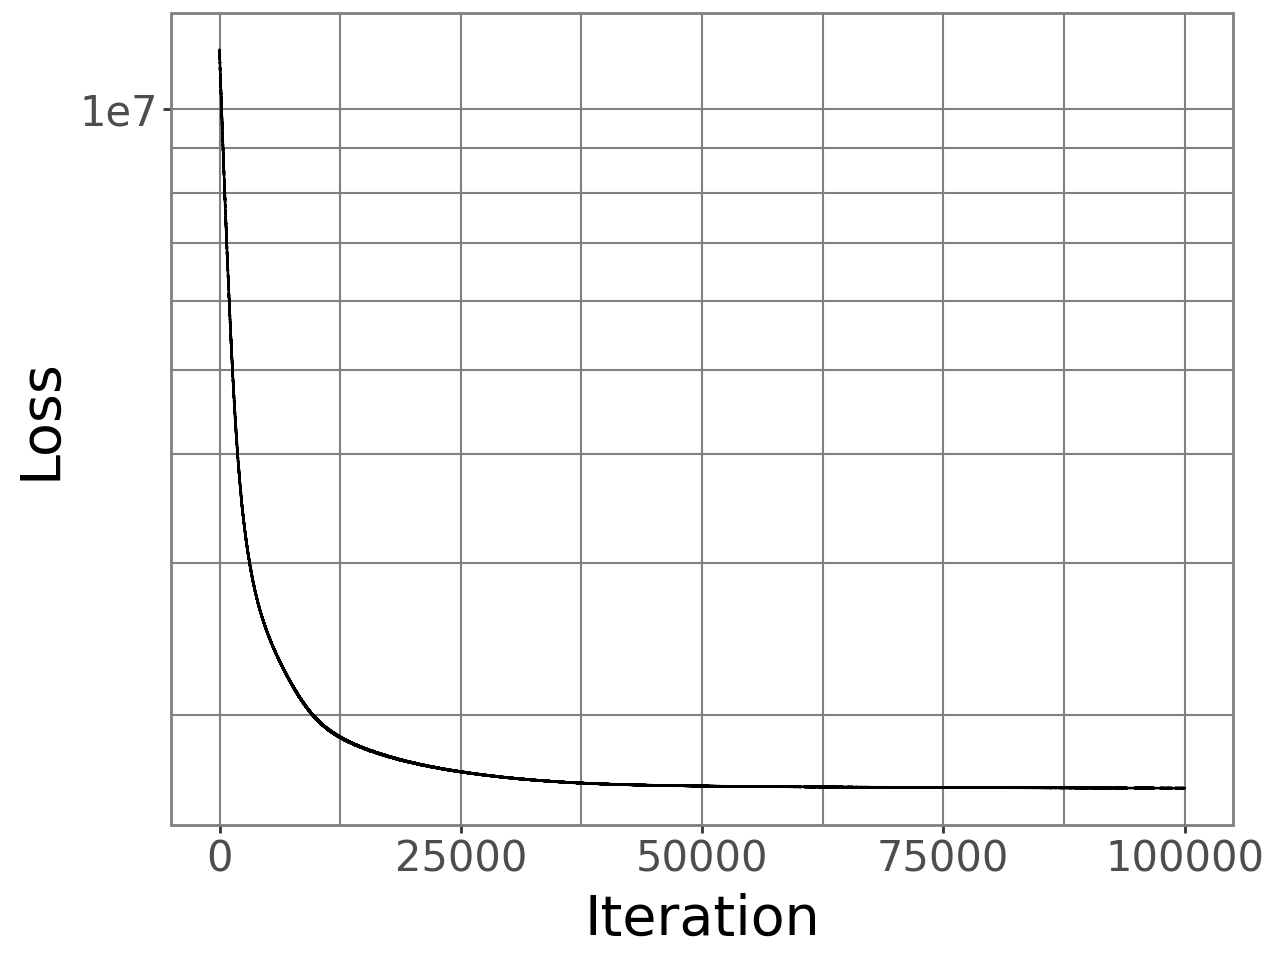

In [16]:
def plot_loss(svi_results):
    df = pd.DataFrame({'loss':svi_results.losses}).reset_index()
    pl = (ggplot(df, aes(x = 'index', y = 'loss')) +
          geom_line() +
          scale_y_log10(breaks=log_breaks, minor_breaks=log_minor_breaks) +
          labs(x = 'Iteration', y = 'Loss') +
          custom_theme)
    return pl

pl = plot_loss(svi_results)
pl.show()

# Results

In [18]:
import gzip
import json

In [19]:
filestem = 'run1sep'
filename = os.path.join(dir_results, f'results_{filestem}.json.gz')
with gzip.open(filename, 'r') as f:
    svi_params = json.load(f)

svi_params = {k: jnp.array(v) for k, v in svi_params.items()}
frequencies = svi_params['frequency']

In [20]:
filename = os.path.join(dir_results, f'data_{filestem}.json.gz')
with gzip.open(filename, 'r') as f:
    data_dict = json.load(f)

In [21]:
data_dict.keys()

dict_keys(['F', 'X_rec', 'X_eq', 'X_stat', 'X_id', 'Y', 'nl_model_dict', 'global_dict', 'attn_eq', 'attn_Q', 'regularize_grad', 'calc_nft', 'ref_basin_id', 'estimate_gs_break', 'estimate_zt_break', 'freq_id_grad', 'dist_cell', 'save_f_nl', 'func_gs_scaling', 'estimate_gs_exp', 'calc_dWS', 'calc_log_lik', 'sharing_config', 'regularization_sigma', 'include_mag_unc'])

## Coefficients

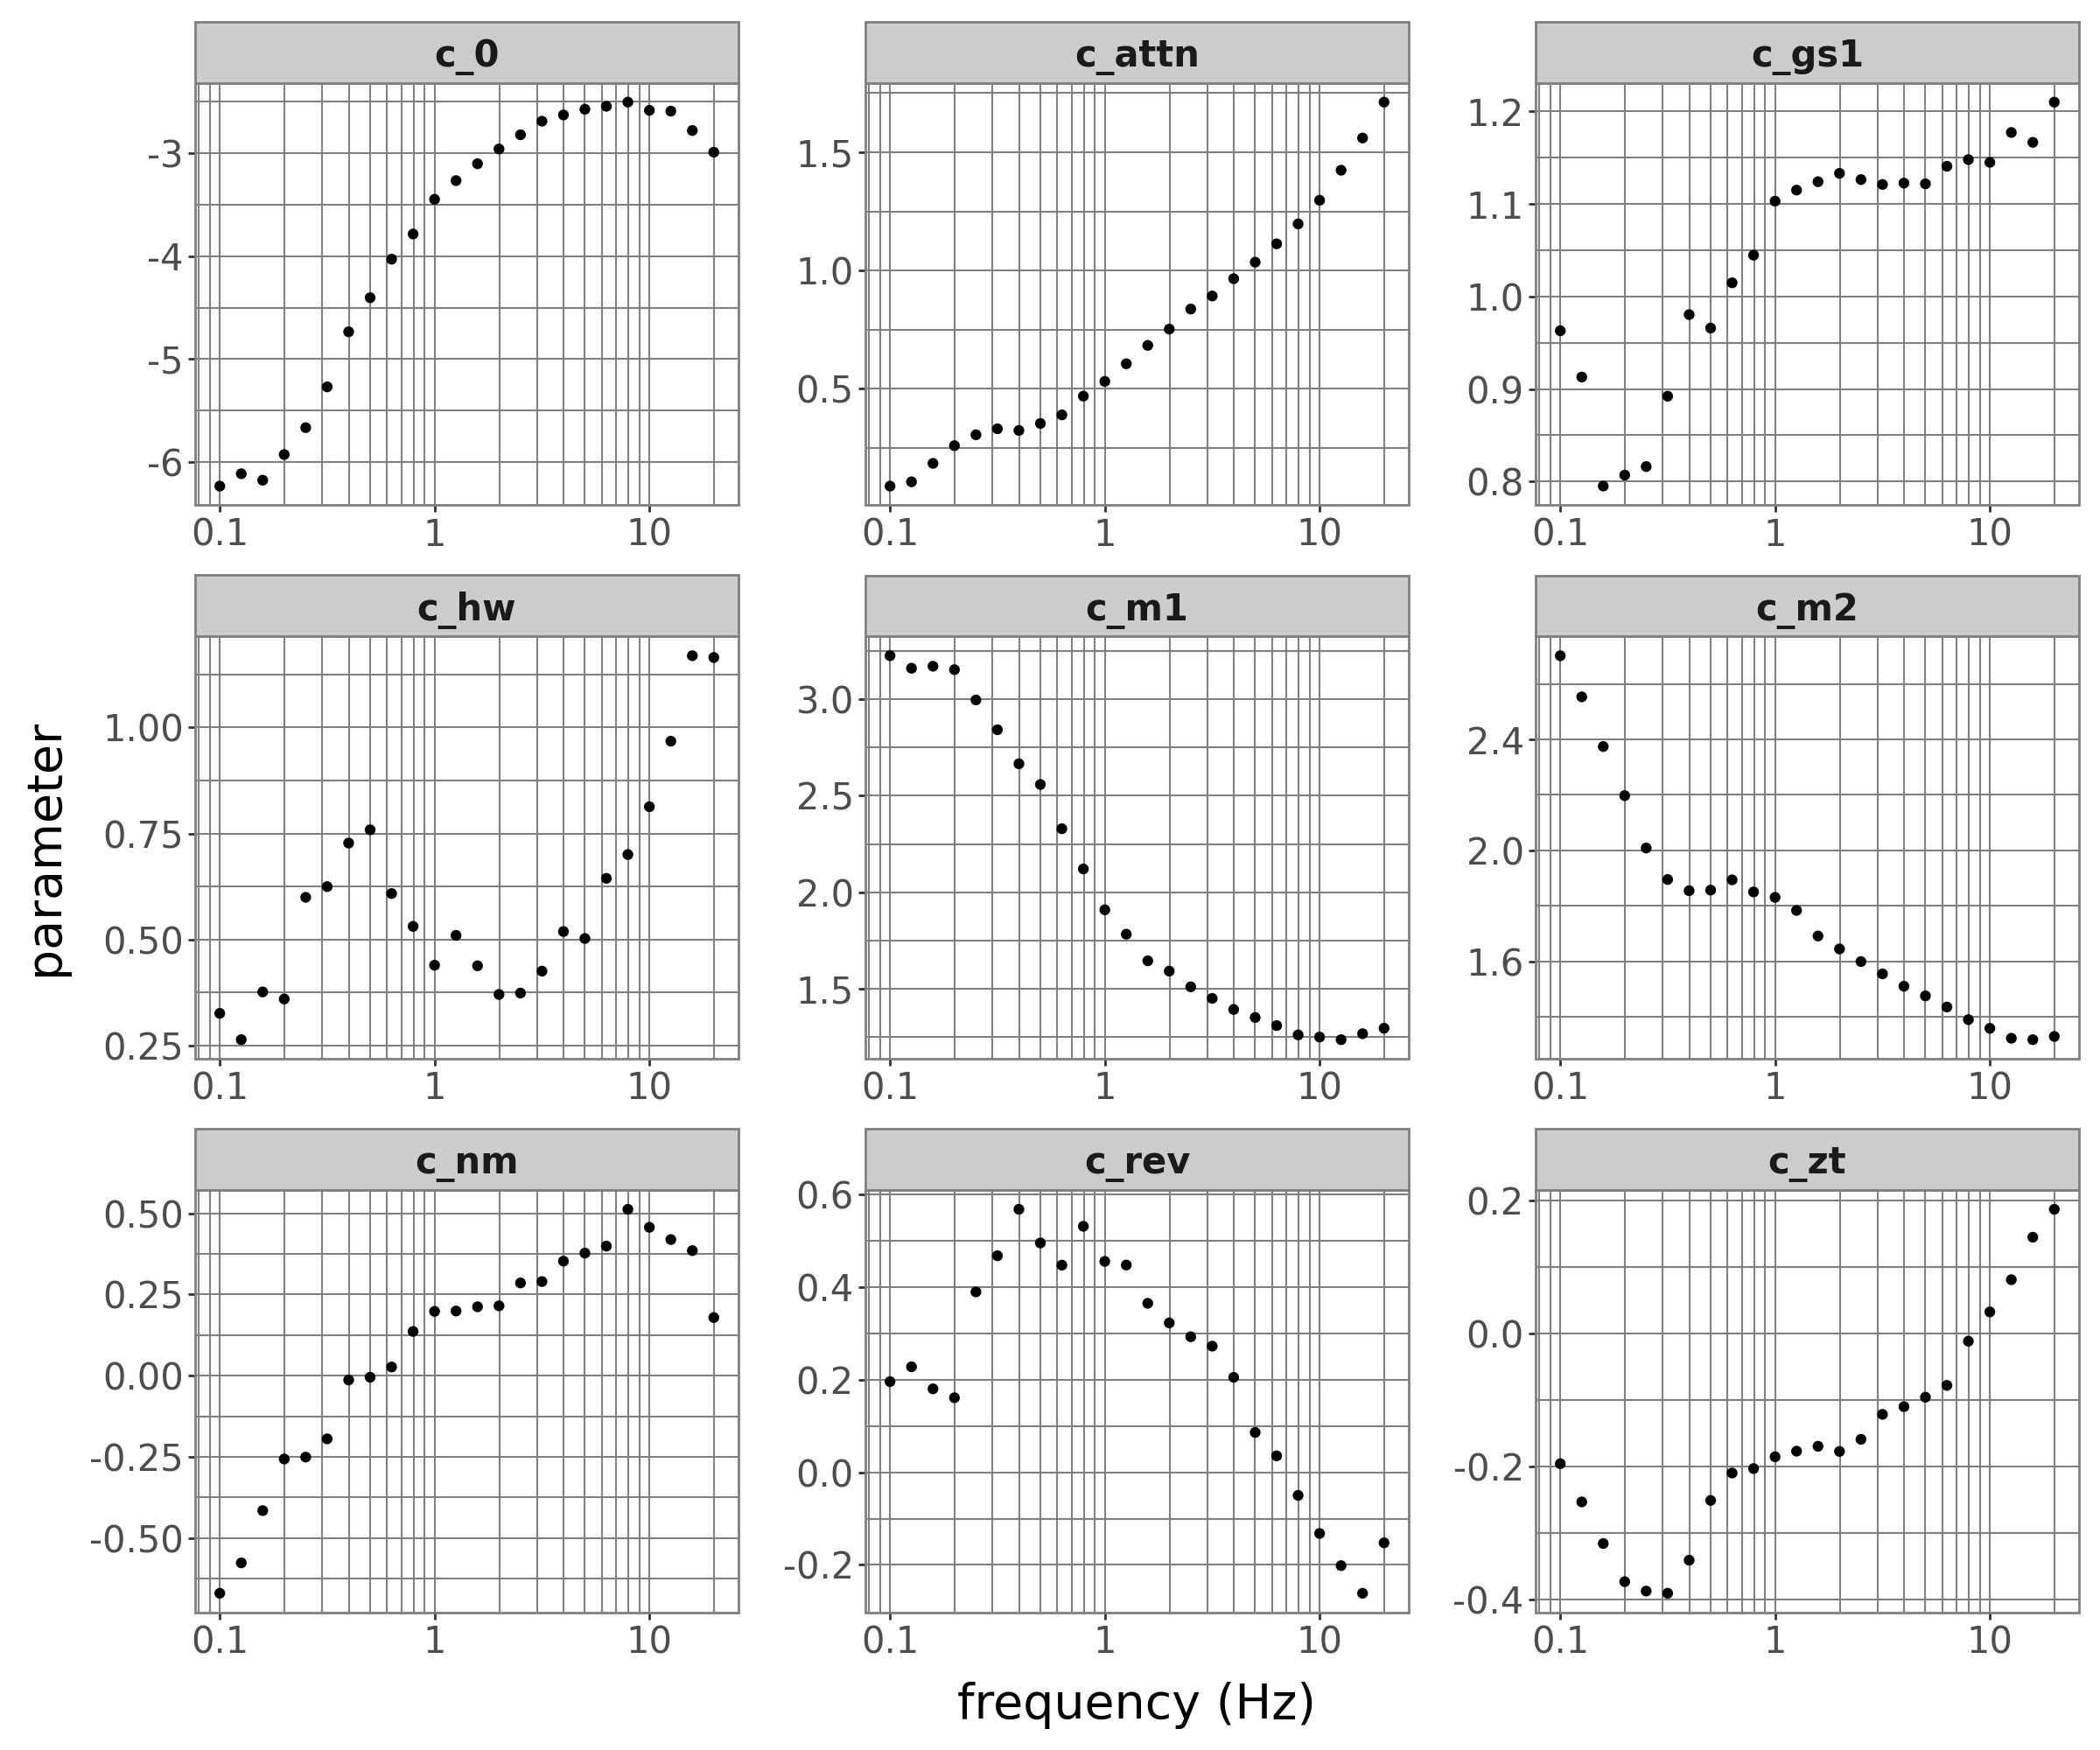

In [33]:
def plot_parameter_against_frequency_facet_svi(deterministics,
                                               plot_vars = ['c_0', 'c_gs1', 'c_nm',
                                                            'c_rev', 'c_hw', 'c_zt',
                                                            'c_m1', 'c_m2', 'c_attn']):


    dfs = []
    for var in plot_vars:
        df_p = pd.DataFrame({'freq': deterministics['frequency'],
                            'mean': deterministics[var],
                            'var': var})
        dfs.append(df_p)
    df = pd.concat(dfs, ignore_index=True)

    pl = (ggplot(df, aes(x='freq', y='mean')) +
          geom_point() +
          facet_wrap('~ var', scales = 'free') +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          labs(x = 'frequency (Hz)', y = 'parameter') +
          custom_theme +
          theme(figure_size=(12, 10)))
    return pl
plot_parameter_against_frequency_facet_svi(svi_params)

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/c_basin.pdf


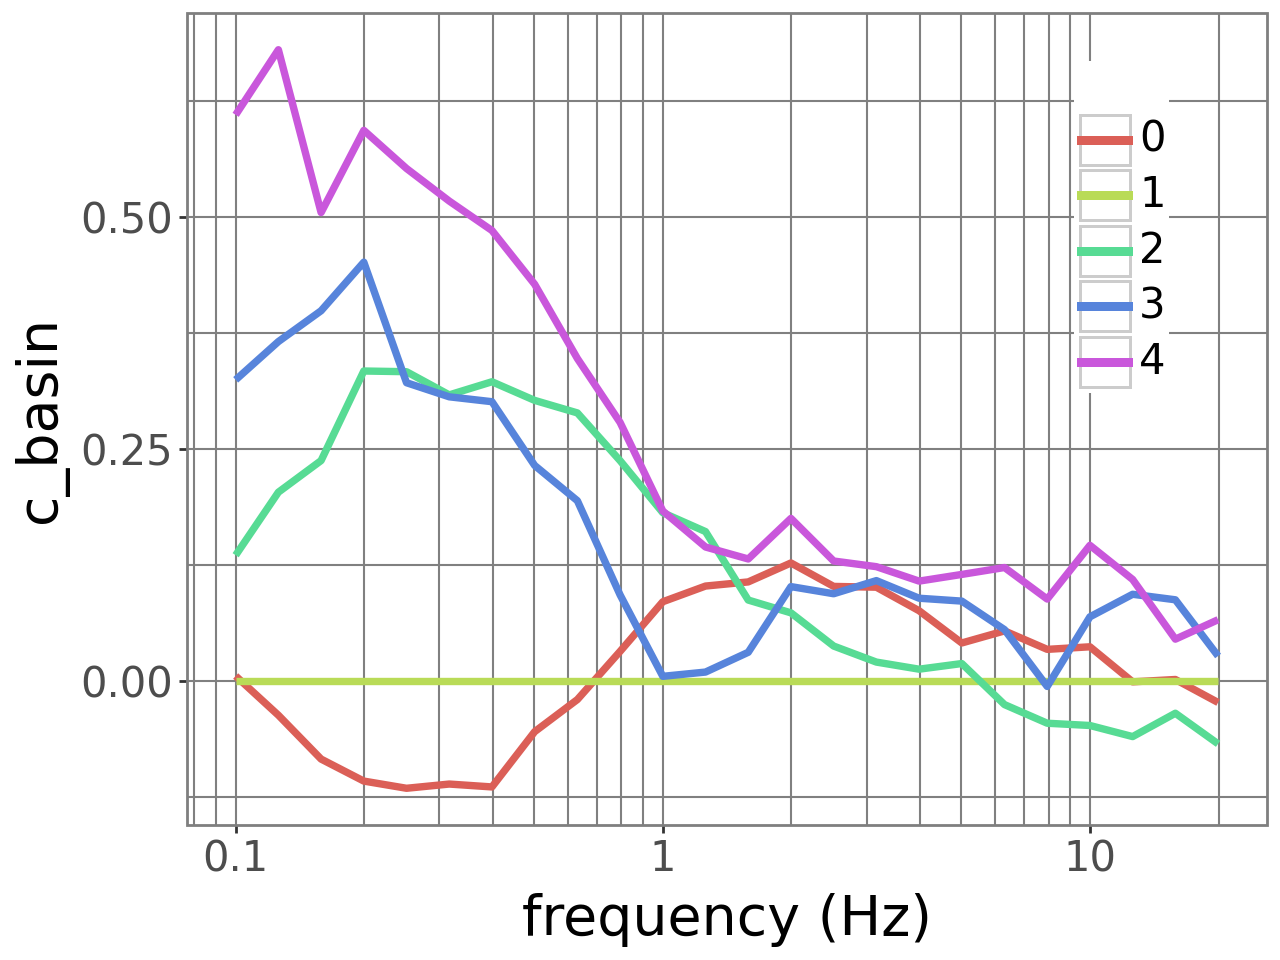

In [35]:
def plot_basin_against_frequency(svi_params):
    df = pd.DataFrame(svi_params['c_basin'].T)
    df['frequency'] = svi_params['frequency']
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
      geom_line(size = 1.5) +
      scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      labs(y = 'c_basin', x = 'frequency (Hz)', color = '') +
      custom_theme +
      theme(legend_position = 'inside',
            legend_position_inside = (0.9,0.9)))
    return pl

pl = plot_basin_against_frequency(svi_params)
ggsave(pl, os.path.join(dir_plot, 'c_basin.pdf'),
                        width = fig_width, height = fig_ratio * fig_width)
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 6.4 in image.
/usr/local/lib/python3.12/dist-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /content/drive/MyDrive/NGAW3/RESULTS/spectrum_eas2/plots/c_m.pdf


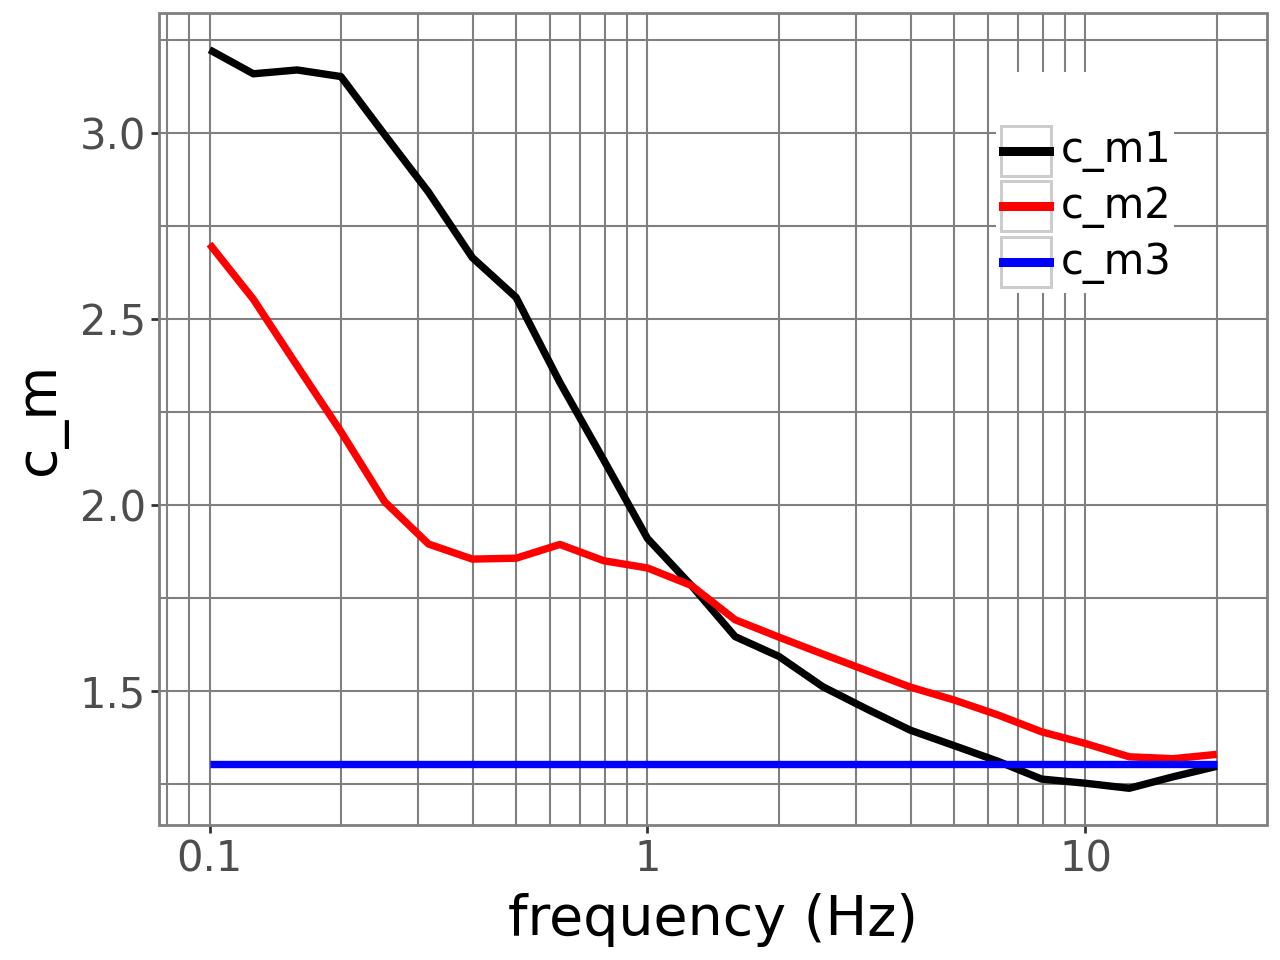

In [36]:
def plot_cm(svi_params):
    df = pd.DataFrame({'frequency': svi_params['frequency'],
                      'c_m1': svi_params['c_m1'],
                      'c_m2': svi_params['c_m2'],
                      'c_m3': np.full(len(svi_params['frequency']), svi_params['c_m3'])})
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
          geom_line(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          scale_color_manual(values=['black', 'red', 'blue']) +
          labs(y = 'c_m', x = 'frequency (Hz)', color = '') +
          custom_theme +
          theme(legend_position = 'inside',
                legend_position_inside = (0.9,0.9)))
    return pl

pl = plot_cm(svi_params)
ggsave(pl, os.path.join(dir_plot, 'c_m.pdf'),
                        width = fig_width, height = fig_ratio * fig_width)
pl.show()

## Standard Deviations

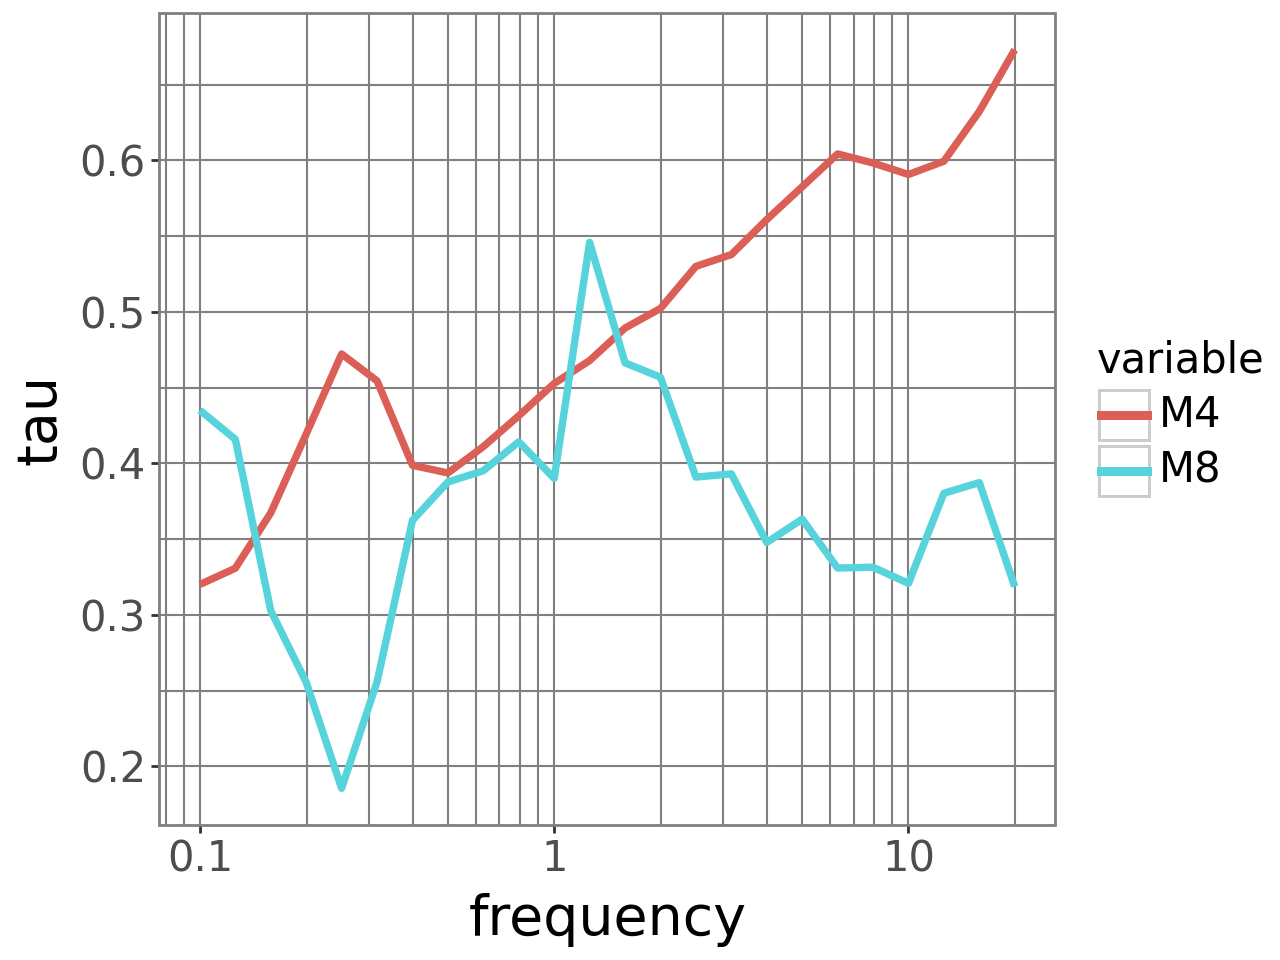

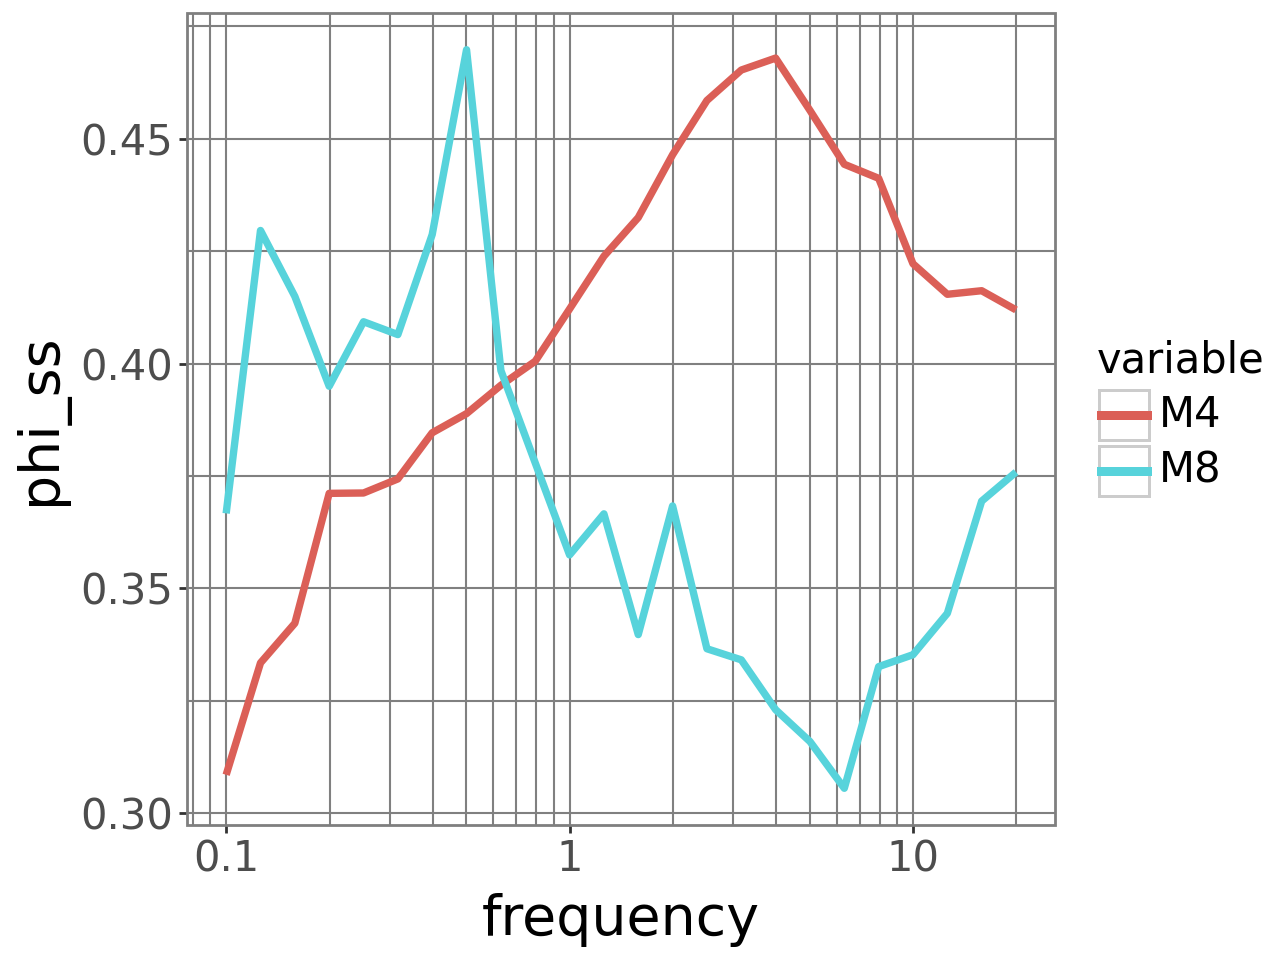

In [ ]:
def plot_sigma(par, deterministics):
    df = pd.DataFrame({'frequency': deterministics['frequency'],
                      'M4': jnp.exp(deterministics[f'{par}_0']),
                      'M8': jnp.exp(deterministics[f'{par}_1'])})
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
          geom_line(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          labs(y = par) +
          custom_theme)
    pl.show()

plot_sigma('tau', svi_params)
plot_sigma('phi_ss', svi_params)

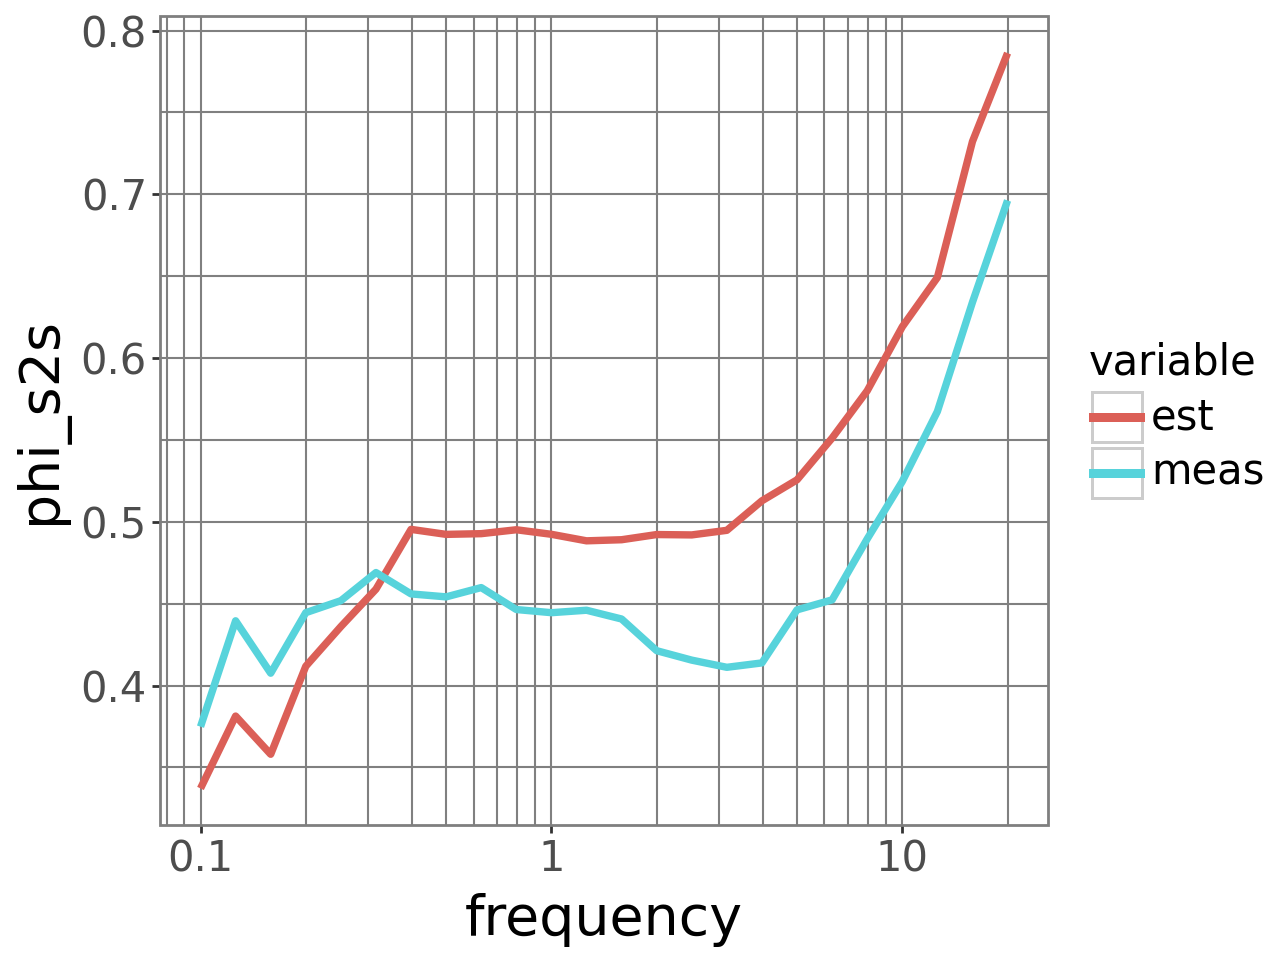

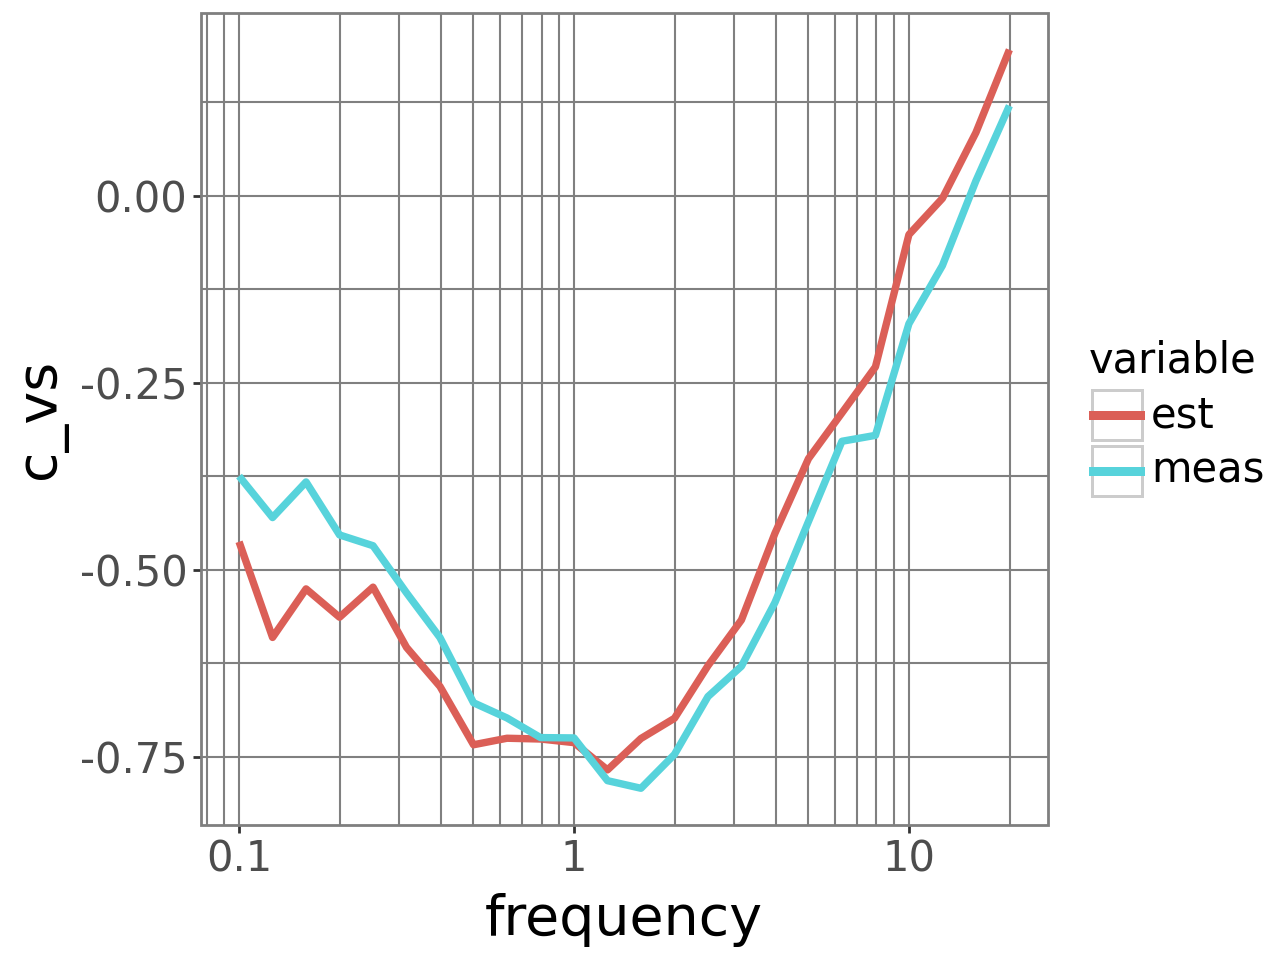

In [ ]:
def plot_sitepars(par, deterministics):
    df = pd.DataFrame({'frequency': deterministics['frequency'],
                      'meas': deterministics[f'{par}_meas'],
                      'est': deterministics[f'{par}_est']})
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', color = 'variable')) +
          geom_line(size = 1.5) +
          scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
          labs(y = par) +
          custom_theme)
    pl.show()

plot_sitepars('phi_s2s', svi_params)
plot_sitepars('c_vs', svi_params)

## Random Effects

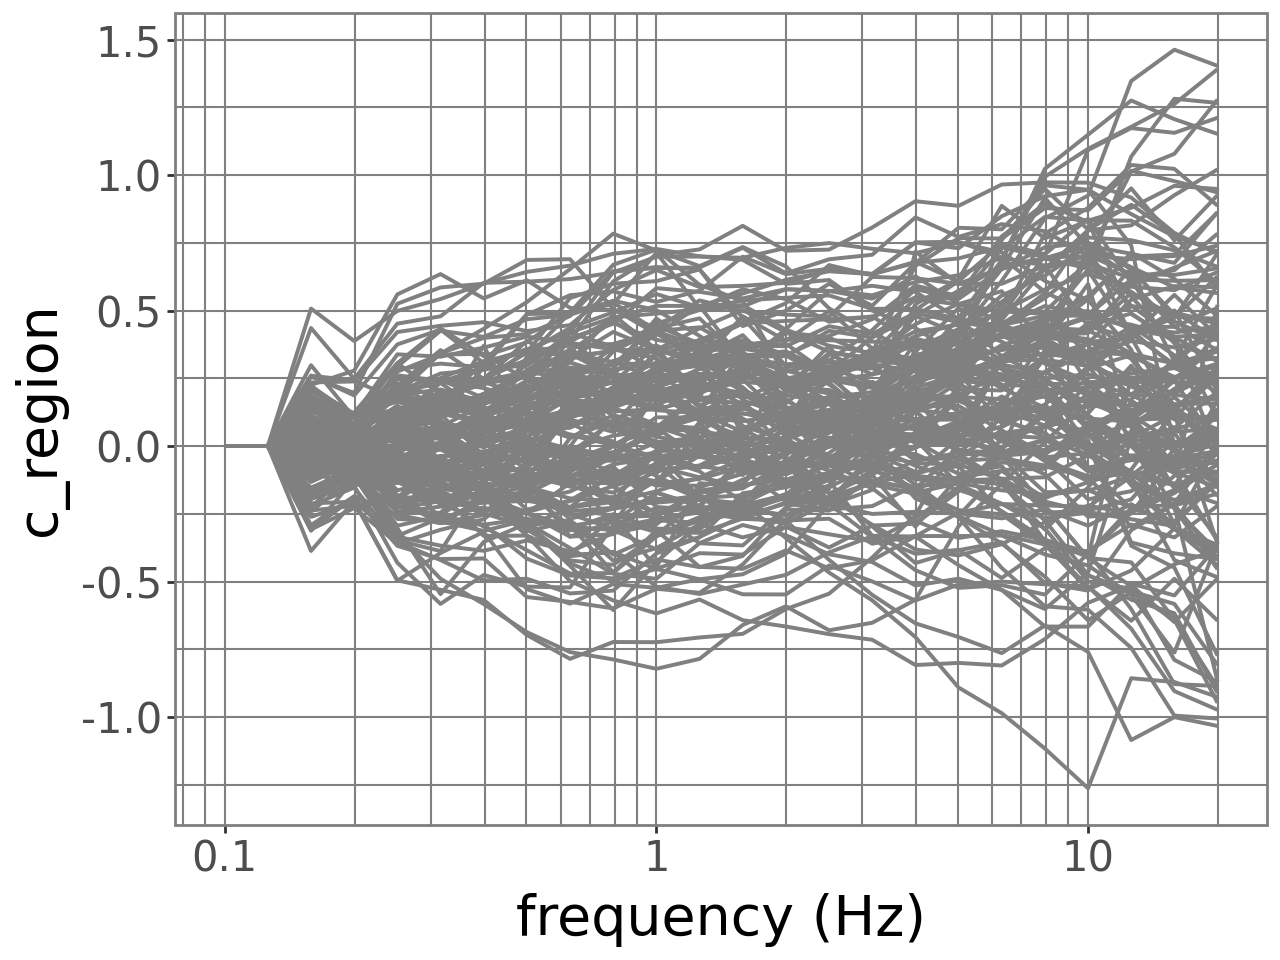

In [ ]:
def plot_region(svi_params):
    df = pd.DataFrame(svi_params['c_region'].T)
    df['frequency'] = svi_params['frequency']
    df = pd.melt(df, id_vars = 'frequency')

    pl = (ggplot(df, aes(x = 'frequency', y = 'value', group = 'variable')) +
      geom_line(size = 0.8, color = 'gray') +
      scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      labs(y = 'c_region', x = 'frequency (Hz)') +
      custom_theme)
    return pl

pl = plot_region(svi_params)
pl.show()

In [ ]:
def plot_random_effect(svi_params, data, re_name, xvar, freq_id=[7,10,17,20],
                       log_x = False, ncol=None):
    freqs = svi_params['frequency']
    freq_names = np.array([f'f = {f:.3f}Hz' for f in freqs])

    df_val = pd.DataFrame(svi_params[re_name], columns=freq_names)
    df_val['x'] = data[xvar]
    df_val = pd.melt(df_val, id_vars='x', value_vars=freq_names[freq_id], value_name='value')

    df_scale = pd.DataFrame(svi_params[f'scale_{re_name}'], columns=freq_names)
    df_scale['x'] = data[xvar]
    df_scale = pd.melt(df_scale, id_vars='x', value_vars=freq_names[freq_id], value_name='scale')

    df = df_val.copy()
    df['scale'] = df_scale['scale']
    df['ymin'] = df['value'] - df['scale']
    df['ymax'] = df['value'] + df['scale']

    n = len(freq_id)
    if ncol is None:
        ncol = np.ceil(np.sqrt(n))
    nrow = np.ceil(n / ncol)

    pl = (ggplot(df, aes(x='x', y='value')) +
          geom_pointrange(aes(ymin='ymin', ymax='ymax'), size=2, fatten=2, raster = True) +
          facet_wrap('~variable', ncol=ncol, scales = 'free') +
          geom_smooth(method='lowess', color='red') +
          labs(x=xvar, y=re_name) +
          custom_theme)
    if log_x:
        pl = pl + scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks)
    return pl

/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


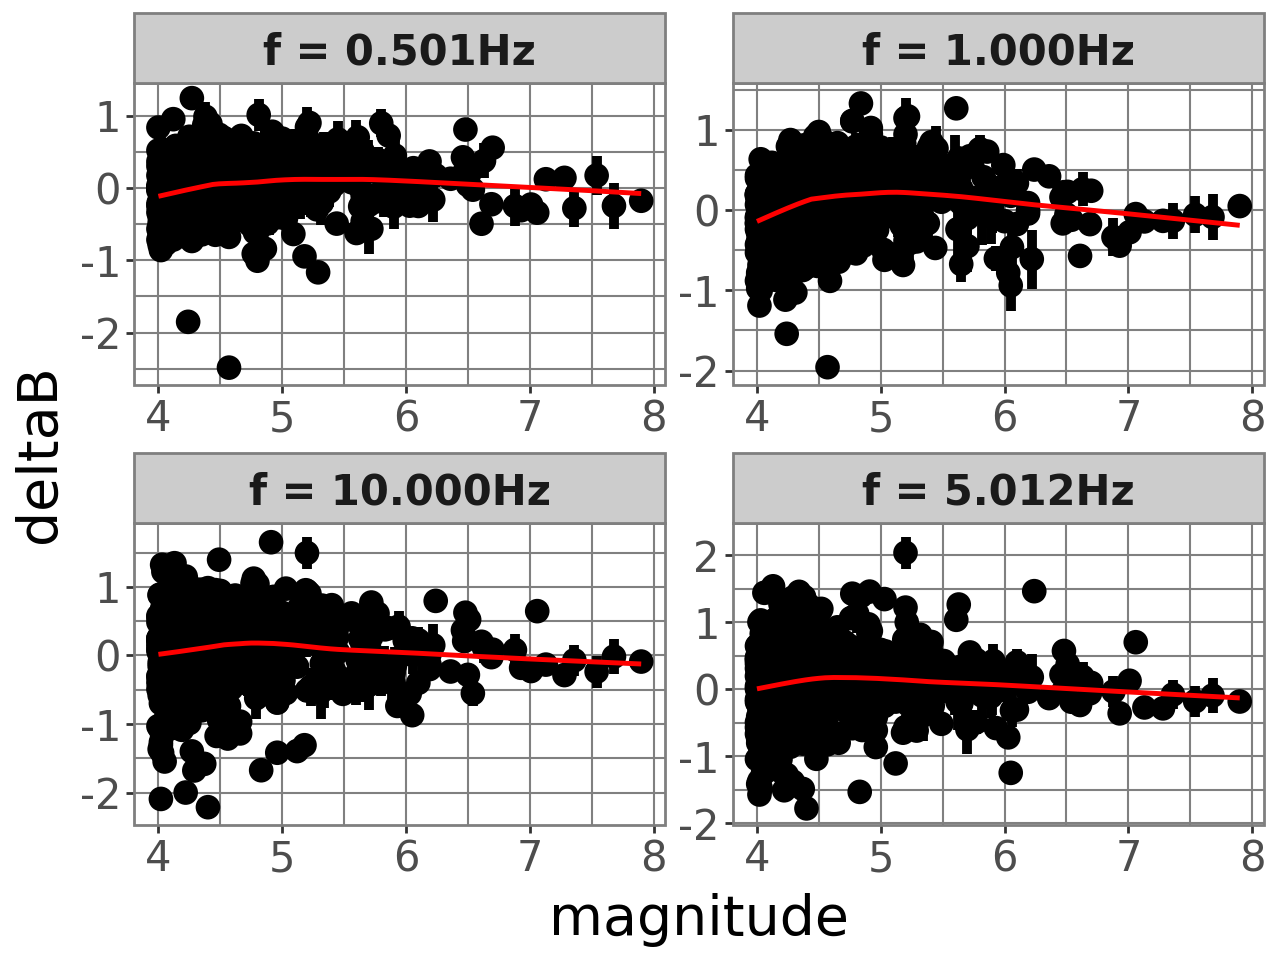

In [ ]:
pl = plot_random_effect(svi_params, data_eq, 'deltaB', 'magnitude')
pl.show()

/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.
/usr/local/lib/python3.12/dist-packages/plotnine/stats/smoothers.py:347: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


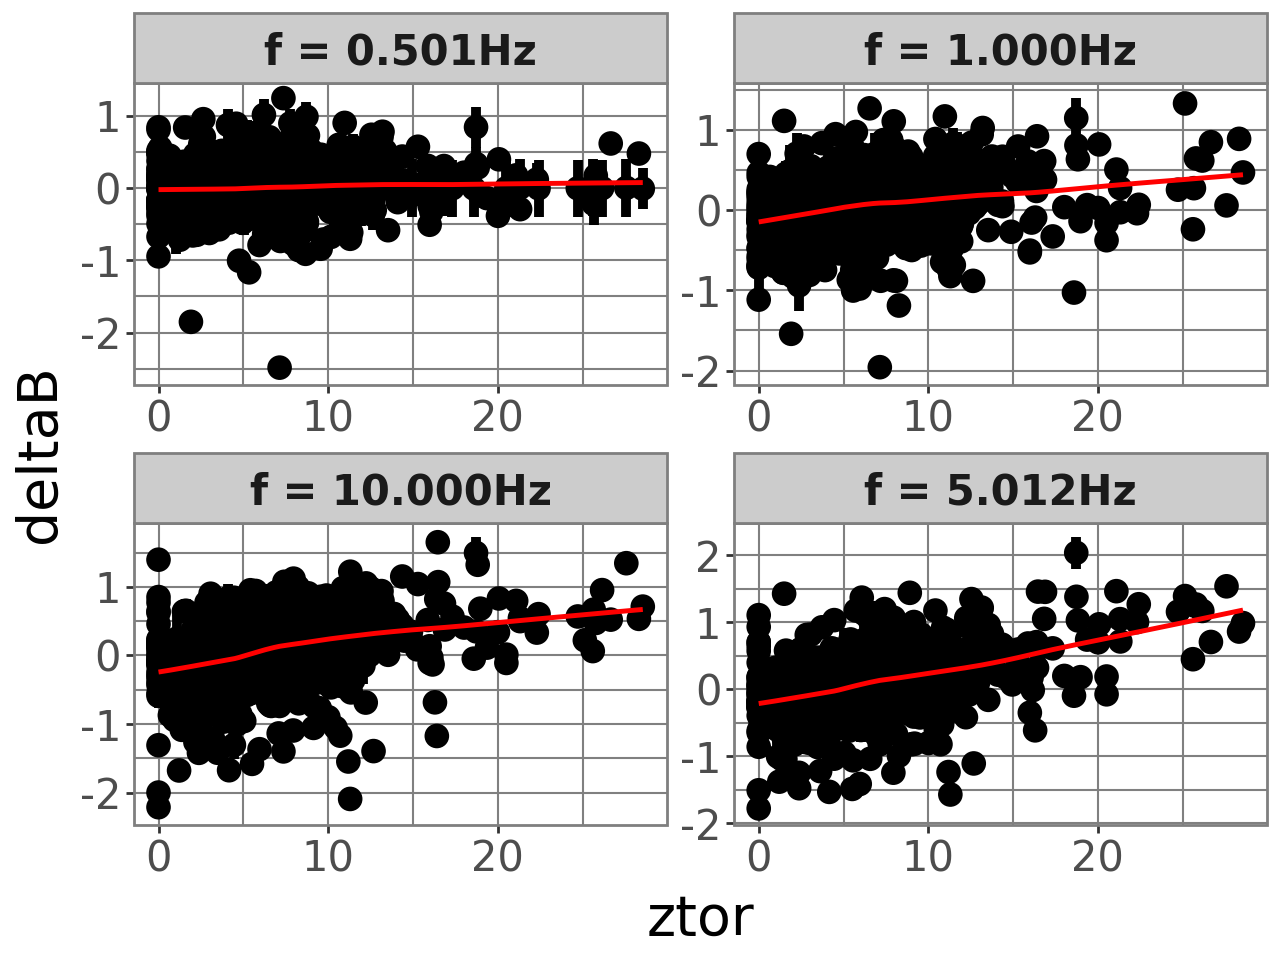

In [ ]:
pl = plot_random_effect(svi_params, data_eq, 'deltaB', 'ztor')
# pl.save(os.path.join(dir_plot, 'deltaB_ztor.pdf'))
pl.show()

## Single-Site Residuals

In [22]:
from ngaw3_kuehnetal27.scenario_prediction import compute_deltaWS

In [28]:
deltaWS = compute_deltaWS(data_dict, svi_params)
deltaWS.shape

(58063, 24)

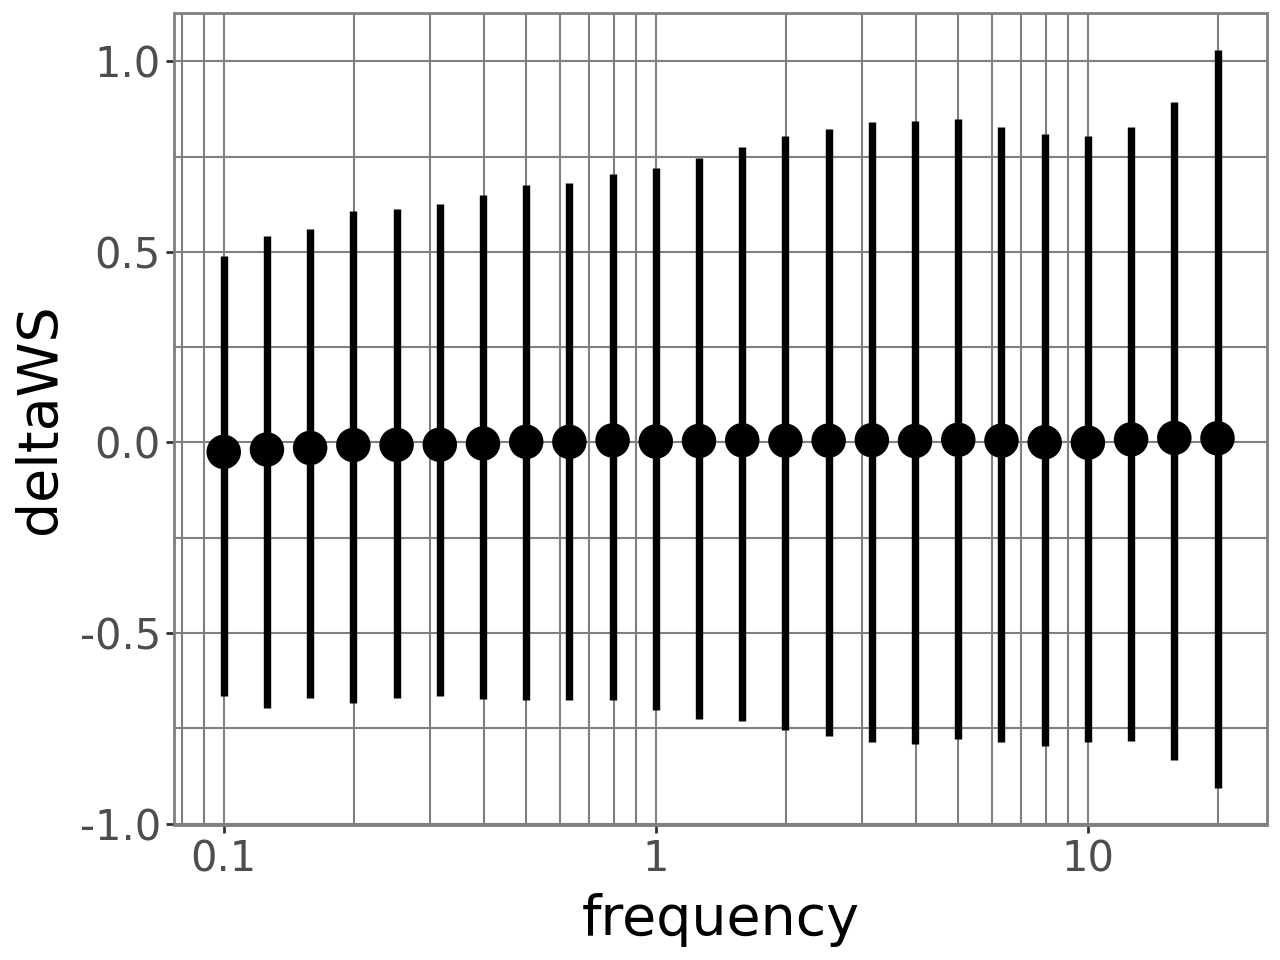

In [29]:
df = pd.DataFrame({'frequency': svi_params['frequency'],
                   'mean': np.nanmean(deltaWS, axis = 0),
                   'q05': np.nanquantile(deltaWS, 0.05, axis = 0),
                   'q95':np.nanquantile(deltaWS, 0.95, axis = 0)})

pl = (ggplot(df, aes(x = 'frequency', y = 'mean', ymin = 'q05', ymax = 'q95')) +
      geom_pointrange(size = 1.5) +
      scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks) +
      labs(y = 'deltaWS') +
      custom_theme)
pl.show()

In [ ]:
def plot_deltaWS(deltaWS, data, xvar, freqs, freq_id=[7,10,17,20],
                       log_x = False, ncol=None):
    freq_names = np.array([f'f = {f:.3f}Hz' for f in freqs])

    df = pd.DataFrame(deltaWS, columns=freq_names)
    df['x'] = data[xvar]
    df = pd.melt(df, id_vars='x', value_vars=freq_names[freq_id], value_name='value')

    n = len(freq_id)
    if ncol is None:
        ncol = np.ceil(np.sqrt(n))
    nrow = np.ceil(n / ncol)

    pl = (ggplot(df, aes(x='x', y='value')) +
          geom_point(size=2, raster = True) +
          facet_wrap('~variable', ncol=ncol, scales = 'free') +
          geom_smooth(method='lowess', color='red') +
          labs(x=xvar, y='deltaWS') +
          custom_theme)
    if log_x:
        pl = pl + scale_x_log10(breaks = log_breaks, minor_breaks = log_minor_breaks)
    return pl

In [ ]:
pl = plot_deltaWS(deltaWS, data_used, 'rrup', frequencies_used, log_x = True)

In [30]:
df = pd.DataFrame(np.abs(deltaWS), columns=frequencies_used_names)
df['motion_id'] = data_used['motion_id']
mask = (df[frequencies_used_names] > 4).any(axis=1)
outlier_ids_dWS = df.loc[mask, 'motion_id'].unique()
pd.DataFrame(outlier_ids_dWS, columns=['motion_id']).to_csv(os.path.join(dir_results, 'outlier_ids_dWS_sep.csv'), index=False)

In [32]:
outlier_ids_dWS

array([  8732,   8773,   9058,   9307,   9490,  10036,  10178,  10444,
        10683,  11351,  18028,  22438,  22773,  23252,  24003,  24172,
        25838,  26047,  26991,  30513,  30536,  30547,  32133,  32439,
        32897,  33453,  35322,  35342,  36018,  37605,  37906,  38283,
        39182,  39223,  66538,  75322,  75327,  75334,  75457,  75462,
        75464,  75465,  75537,  75540,  75564,  75571,  75573,  75595,
        75596,  76823,  76824,  76825,  76827,  76828,  76829,  76830,
        76834,  76835,  76836,  77938,  77945,  77946,  77947,  77949,
        77955,  77960,  77962,  77964,  77972,  77977,  77994,  78113,
        78116,  78197,  78202,  78203,  78215,  78787,  79131,  79179,
        79312,  79313,  79317,  79957,  80213,  81061,  81062,  81627,
        81930,  81951,  81965,  81981,  81997,  82004,  82498,  82500,
        82505,  82512,  82524,  82527,  82529,  82532,  82536,  82546,
        82551,  82553,  82558,  82578,  82585,  82586,  82603,  82606,
      

In [37]:
deltaR = (svi_params['deltaB'][data_dict['X_id'][:,0]] +
 svi_params['deltaB_attn'][data_dict['X_id'][:,0]] * data_dict['X_rec'][:,0][:,jnp.newaxis] / 100 +
 svi_params['deltaS'][data_dict['X_id'][:,1]] +
 deltaWS)

In [38]:
df = pd.DataFrame(np.abs(deltaR), columns=frequencies_used_names)
df['motion_id'] = data_used['motion_id']
mask = (df[frequencies_used_names] > 5).any(axis=1)
df.loc[mask, 'motion_id'].unique()

array([  9058,  10036,  10178,  10683,  12374,  12375,  12376,  12378,
        24665,  26047,  26991,  29646,  29718,  29835,  30165,  30191,
        30195,  30284,  30349,  30374,  30507,  30512,  30513,  30517,
        30560,  30563,  30684,  31091,  31478,  31603,  31604,  31606,
        31708,  31742,  31751,  31760,  31762,  32318,  32937,  33032,
        33491,  33742,  33862,  33863,  34195,  34298,  34303,  34321,
        34366,  34392,  34446,  34462,  34465,  34501,  34513,  34518,
        34557,  34571,  34576,  34641,  34775,  34876,  34919,  34994,
        35079,  35080,  35409,  35410,  35447,  35509,  35513,  35900,
        37706,  38389,  38480,  38505,  38574,  38665,  75322,  75334,
        75457,  75462,  75464,  75465,  75537,  75540,  75571,  75573,
        75595,  75596,  76576,  76823,  76824,  76825,  76827,  76829,
        76830,  76834,  76835,  76836,  76876,  76888,  76889,  76891,
        77870,  77935,  77938,  77940,  77945,  77946,  77947,  77949,
      